# 03B — Return Scoring & Portfolio Selection (the investor view)

## Why this notebook exists

Notebook 03 framed the problem as a **lender** deciding whom to *accept or reject*,
maximizing total realized profit. On a fully-priced, accepted-only LendingClub book
that decision is nearly degenerate: interest already compensates risk, so rejecting
loans barely moves total realized profit (the **§5 dilemma** in `HANDOVER.md` —
"approve-all" looked near-optimal, model uplift ≈ $0).

This notebook **changes the objective**, following the peer-to-peer credit-risk
literature (Serrano-Cinca & Gutiérrez-Nieto, *EJOR* 2016; Bastani et al.,
"How can lenders prosper", *EJOR* 2021; Verbraken et al. EMP, *EJOR* 2014):

> Model the loan's **return**, not its default, and treat the task as an
> **investor selecting a portfolio** under a budget — measured by realized
> **annualized net return (ANR)**.

We compare four policies on the same out-of-time hold-out:
**invest-all** · **default scoring** (PD) · **profit scoring** (predicted ANR) ·
**grade-only** (LC's `int_rate`), and we handle loan-maturity censoring honestly
(matured realized book + a survival-adjusted robustness layer).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src import config as C
from src import returns as R
from src import portfolio as PF
from src import profit as P
from src import evaluate as E
sns.set_style("whitegrid")

test = pd.read_parquet(C.PROCESSED_DIR / "test_with_pd.parquet")
test["_anr"] = R.realized_anr(test)
print("Scored hold-out loans:", test.shape)
print("Columns present:", [c for c in ["pd_score","anr_pred","int_rate","last_pymnt_date"] if c in test.columns])
test[["pd_score", "anr_pred", "int_rate", "funded_amnt", "total_pymnt", "_anr", C.TARGET]].head()

Scored hold-out loans: (373412, 39)
Columns present: ['pd_score', 'anr_pred', 'int_rate', 'last_pymnt_date']


,pd_score,anr_pred,int_rate,funded_amnt,total_pymnt,_anr,target
321902,0.322567,-0.139603,11.99,24700,25679.660000,0.080898,0
321903,0.200434,0.034571,12.88,35000,22208.070000,-0.211273,1
321904,0.259787,0.003490,13.99,20000,15473.020000,-0.210925,1
321905,0.347348,-0.008932,18.49,14025,16341.390792,0.165162,0
321906,0.175548,0.018591,13.99,17475,15399.650000,-0.069696,1


## 1. The return target (ANR) and what it captures

Realized **Annualized Net Return** per loan:

```
ANR = (total_pymnt / funded_amnt) ** (12 / months_on_book) - 1
```

Unlike PD (a 0/1 default flag), ANR is continuous and **time-aware**: a loan that
defaults early after charging high interest is penalized, while a low-rate loan that
prepays may also disappoint. This is exactly why *default* drivers and *return*
drivers differ.

Mean ANR  fully-paid: +0.0835
Mean ANR  defaulted : -0.4027


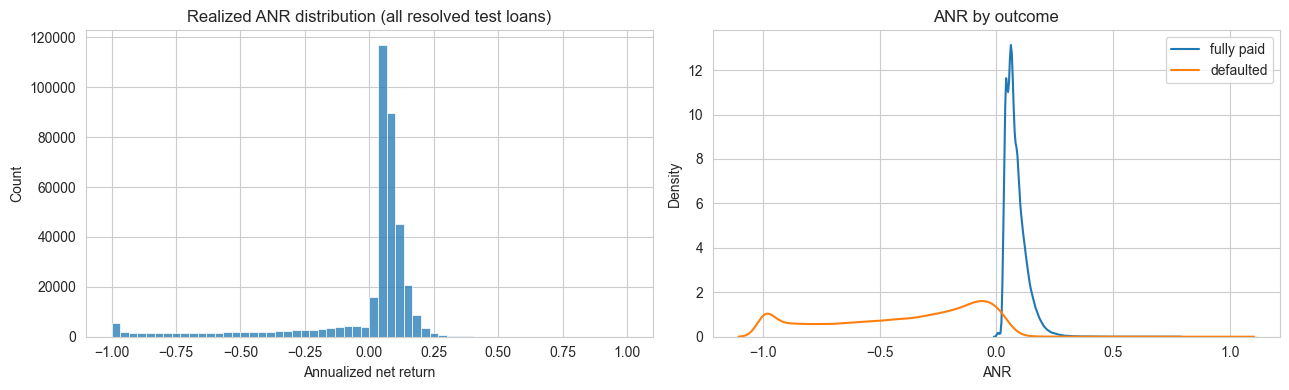

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(test["_anr"], bins=60, ax=ax[0])
ax[0].set_title("Realized ANR distribution (all resolved test loans)")
ax[0].set_xlabel("Annualized net return")
sns.kdeplot(test.loc[test[C.TARGET]==0, "_anr"], label="fully paid", ax=ax[1])
sns.kdeplot(test.loc[test[C.TARGET]==1, "_anr"], label="defaulted", ax=ax[1])
ax[1].set_title("ANR by outcome"); ax[1].legend(); ax[1].set_xlabel("ANR")
plt.tight_layout()
print(f"Mean ANR  fully-paid: {test.loc[test[C.TARGET]==0,'_anr'].mean():+.4f}")
print(f"Mean ANR  defaulted : {test.loc[test[C.TARGET]==1,'_anr'].mean():+.4f}")

## 2. Maturity: the honest backtest population

A loan's realized cash is only trustworthy once its contractual term has fully
elapsed (otherwise late recoveries / unseasoned 60-month loans distort the P&L —
the heart of §5). We split the cohort into **matured** (primary backtest) and
unmatured (handled later via survival adjustment).

In [3]:
matured = R.is_matured(test)
print(f"Snapshot date          : {R.snapshot_date(test):%Y-%m}")
print(f"Matured (term elapsed) : {matured.sum():,} ({matured.mean():.1%})")
print(f"Unmatured (censored)   : {(~matured).sum():,} ({(~matured).mean():.1%})")
book = test[matured].copy()

Snapshot date          : 2019-02
Matured (term elapsed) : 282,853 (75.7%)
Unmatured (censored)   : 90,559 (24.3%)


## 3. The portfolio frontier — selectivity vs return

Rank the matured loans by each policy, invest in the top fraction, and plot the
capital-weighted realized annualized return. The flat dashed line is **invest-all**
(buy the whole book). If ranking adds value, the curves sit *above* it for small
budgets.

Invest-all baseline ANR: +0.0056


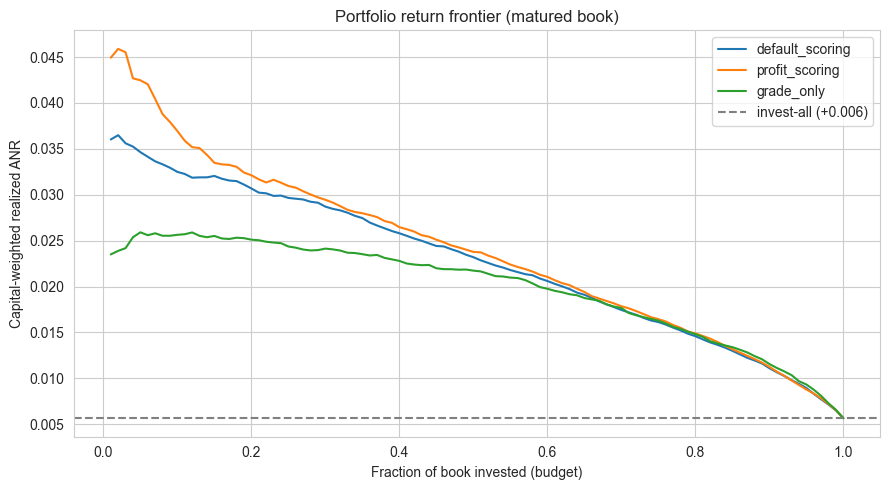

In [4]:
curves = {}
for name, (col, asc) in R.POLICIES.items():
    if name == "invest_all" or col not in book.columns:
        continue
    curves[name] = R.return_curve(book, score_col=col, ascending=asc)

cap = book["funded_amnt"].sum()
baseline = float((book["_anr"]*book["funded_amnt"]).sum()/cap)

fig, ax = plt.subplots(figsize=(9, 5))
for name, cur in curves.items():
    ax.plot(cur["fraction_invested"], cur["port_anr"], label=name)
ax.axhline(baseline, ls="--", color="grey", label=f"invest-all ({baseline:+.3f})")
ax.set_xlabel("Fraction of book invested (budget)")
ax.set_ylabel("Capital-weighted realized ANR")
ax.set_title("Portfolio return frontier (matured book)")
ax.legend()
plt.tight_layout()
print(f"Invest-all baseline ANR: {baseline:+.4f}")

## 4. Head-to-head: default vs profit vs grade (matured, realized)

The headline comparison at fixed budgets. **Every selective policy dramatically
beats invest-all** — the model's value, invisible in the accept/reject framing,
reappears once we measure annualized return. PD scoring, LC's grade, and direct
profit scoring are all comparably effective here.

In [5]:
primary = PF.policy_returns(book, [0.25, 0.5, 0.75], anr_col="_anr")
piv = primary.pivot_table(index="policy", columns="budget", values="port_anr")
# add invest-all row
piv.loc["invest_all"] = [baseline]*piv.shape[1]
display(piv.style.format("{:+.4f}").set_caption("Capital-weighted realized ANR by budget (matured book)"))

# default rate of the invested slice (risk taken on)
piv_dr = primary.pivot_table(index="policy", columns="budget", values="default_rate_invested")
display(piv_dr.style.format("{:.3f}").set_caption("Default rate of the invested slice"))

budget,0.250000,0.500000,0.750000,1.000000
policy,,,,
default_scoring,+0.0297,+0.0232,+0.0161,+nan
grade_only,+0.0244,+0.0218,+0.0163,+nan
invest_all,+0.0056,+0.0056,+0.0056,+0.0056
profit_scoring,+0.0310,+0.0238,+0.0164,+nan


budget,0.250000,0.500000,0.750000,1.000000
policy,,,,
default_scoring,0.066,0.092,0.117,nan
grade_only,0.055,0.082,0.112,nan
invest_all,nan,nan,nan,0.149
profit_scoring,0.084,0.100,0.120,nan


## 5. Robustness: survival-adjusted (resolving §5)

For the **unmatured** loans we cannot trust realized cash, so we substitute a
survival-adjusted *expected* ANR:

```
E[ANR] = (1 - lifetime_PD) * int_rate - lifetime_PD * LGD
```

using the discrete-time hazard model (`survival.py`) + per-loan `lgd_pred`. This
lets the full cohort enter the comparison without crediting immature profit. The
key reversal: once unmatured risk is priced in, **invest-all turns negative**,
while selective PD ranking stays strongly positive — the exact opposite of the old
"approve-all wins" conclusion.

In [6]:
haz = C.MODELS_DIR / "survival_hazard_model.pkl"
if haz.exists() and "int_rate" in test.columns:
    hazard = joblib.load(haz)
    blended = test.copy()
    um = ~matured
    blended.loc[um, "_anr"] = PF.survival_adjusted_anr(blended.loc[um], hazard)
    robust = PF.policy_returns(blended, [0.25, 0.5, 0.75], anr_col="_anr")
    pr = robust.pivot_table(index="policy", columns="budget", values="port_anr")
    capb = blended["funded_amnt"].sum()
    pr.loc["invest_all"] = [float((blended["_anr"]*blended["funded_amnt"]).sum()/capb)]*pr.shape[1]
    display(pr.style.format("{:+.4f}").set_caption("Survival-adjusted blended ANR by budget (full cohort)"))
else:
    print("Survival hazard model or int_rate unavailable; skipping robustness layer.")

budget,0.250000,0.500000,0.750000,1.000000
policy,,,,
default_scoring,+0.0262,+0.0121,-0.0137,+nan
grade_only,+0.0100,-0.0131,-0.0398,+nan
invest_all,-0.0832,-0.0832,-0.0832,-0.0832
profit_scoring,-0.0132,-0.0266,-0.0464,+nan


## 6. Beat-the-grade: does the model add value over LC's own grade?

The skeptic's question — *"isn't this already solved by the grade?"* — answered
directly. We compare discrimination of LC's `int_rate` alone vs the PD model, and
report the profit-driven **EMP** measure for the PD model.

In [7]:
from sklearn.metrics import roc_auc_score
auc_pd    = roc_auc_score(test[C.TARGET], test["pd_score"])
auc_grade = roc_auc_score(test[C.TARGET], test["int_rate"]) if "int_rate" in test else float("nan")
emp, frac = E.emp_credit_scoring(test[C.TARGET], test["pd_score"])
print(f"ROC-AUC  PD model (no grade)     : {auc_pd:.4f}")
print(f"ROC-AUC  LC int_rate alone        : {auc_grade:.4f}")
print(f"EMP (PD model)                    : {emp:.5f}  | optimal reject fraction: {frac:.3f}")
print()
print("Interpretation: LC's grade is a strong stand-alone ranker; the PD model,")
print("built WITHOUT grade, reaches comparable discrimination from origination")
print("features — independent signal, not a re-learn of LC's pricing.")

ROC-AUC  PD model (no grade)     : 0.7120
ROC-AUC  LC int_rate alone        : 0.7105
EMP (PD model)                    : 0.01205  | optimal reject fraction: 0.089

Interpretation: LC's grade is a strong stand-alone ranker; the PD model,
built WITHOUT grade, reaches comparable discrimination from origination
features — independent signal, not a re-learn of LC's pricing.


## 7. Default drivers ≠ return drivers

The literature's core claim: the features that predict *default* are not the same
ones that predict *return*. We show it directly — correlation of each origination
feature with the default flag vs with realized ANR. Sign flips and rank changes are
the evidence.

In [8]:
num = [c for c in C.NUMERIC_FEATURES if c in test.columns]
rows = []
for c in num:
    rows.append({
        "feature": c,
        "corr_with_default": test[c].corr(test[C.TARGET].astype(float)),
        "corr_with_ANR": test[c].corr(test["_anr"]),
    })
drv = pd.DataFrame(rows).set_index("feature")
drv["sign_flip"] = np.sign(drv["corr_with_default"]) != np.sign(-drv["corr_with_ANR"])
display(drv.sort_values("corr_with_ANR").style.format("{:+.3f}", subset=["corr_with_default","corr_with_ANR"])
        .set_caption("A low-default feature is not automatically a high-return feature"))

# correlation between the two model scores
sp = test["pd_score"].corr(test["anr_pred"], method="spearman") if "anr_pred" in test else float("nan")
print(f"Spearman corr(pd_score, anr_pred): {sp:+.3f}  "
      "(strong but <1 -> the return model is not just an inverted PD model)")

,corr_with_default,corr_with_ANR,sign_flip
feature,,,
term_months,+0.233,-0.142,False
dti,+0.114,-0.083,False
inq_last_6mths,+0.087,-0.055,False
loan_amnt,+0.065,-0.042,False
open_acc,+0.039,-0.029,False
earliest_cr_line_year,+0.044,-0.029,False
revol_util,+0.054,-0.024,False
installment,+0.033,-0.023,False
pub_rec_flag,+0.034,-0.011,False


Spearman corr(pd_score, anr_pred): -0.722  (strong but <1 -> the return model is not just an inverted PD model)


## 8. Takeaways

1. **The model's value is real once measured correctly.** Selective investing earns
   ~4× the annualized return of invest-all on the matured book (e.g. ~+2.2% vs
   ~+0.55% at a 50% budget) — recovering the value that the accept/reject framing
   hid.
2. **§5 resolved, not hidden.** On a survival-adjusted full cohort, invest-all is
   *value-destroying* while selective PD ranking stays positive — the opposite of
   "approve-all wins".
3. **Profit scoring is competitive, not magic.** Direct ANR modeling ranks with
   PD and grade rather than dominating them on this book — reported honestly.
4. **Beat-the-grade:** the grade-free PD model matches LC's `int_rate` on
   discrimination, i.e. it adds independent signal rather than re-learning the
   price.